# Synthetic playground: hedging under rough volatility with several methodologies

Simulated rough Bergomi data (`rough_hedge`), several hedging methodologies on the **same** test paths: Black-Scholes delta, Leland, Whalley-Wilmott band, and learned hedgers (feed-forward, recurrent, signature-feature). Three visualisation stages: **before** (what the data looks like and how rough it is), **during** (training), **after** (loss distributions and paired comparisons).

> **Scope.** Everything here is simulated. Nothing is evidence of live performance. The training budget is deliberately small so the notebook runs in minutes; conclusions are limited to this budget.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json, math, numpy as np, pandas as pd, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
import io
from rough_hedge.rbergomi import simulate_rbergomi
from rough_hedge.roughness import estimate_hurst
from rough_hedge.experiment import run_comparison, compare_arms
from rough_hedge.risk import cvar_tail_mean
from rough_hedge.stats import holm
from rough_hedge.hedging import hedging_pnl
PAL = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#56B4E9', '#CC79A7', '#6B6B6B']
plt.rcParams.update({'figure.facecolor': 'white', 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})
def show(fig):
    b = io.BytesIO(); fig.savefig(b, format='png', dpi=100, facecolor='white', bbox_inches='tight'); plt.close(fig)
    display(Image(b.getvalue()))
CFG = dict(n_seeds=2, seed=2026, n_train=512, n_val=128, n_test=500, N=30, T=30/365, H=0.1, eta=1.9, rho=-0.7,
           xi0=0.235**2, cost_bp=10.0, arms=('bs_delta', 'leland', 'ww_band', 'ffn', 'gru', 'sig2'),
           epochs=3, batch_size=128, lr=5e-3, patience=3, width=16, ww_gamma=10.0, device='cpu')
ARMS = CFG['arms']


## 1. Before: what the synthetic world looks like
Variance paths for a rough (H = 0.1) and a smoother (H = 0.4) specification with the same forward variance and vol-of-vol.

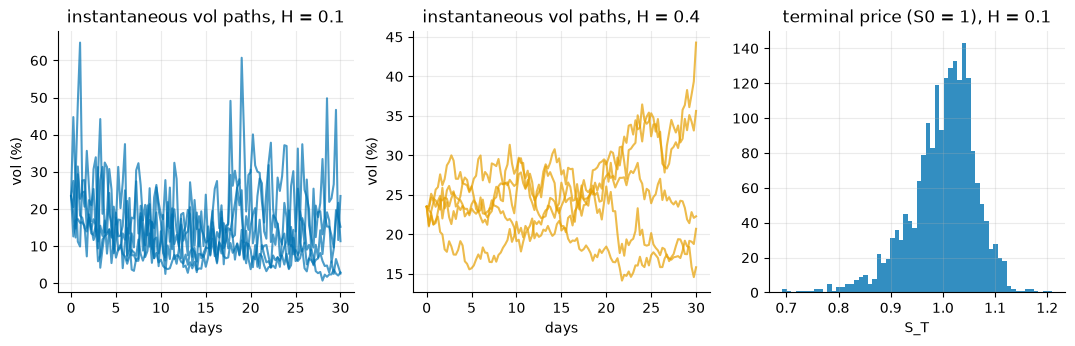

CHECK mean terminal price (martingale, expect ~1): 1.0009 +/- 0.0014


In [2]:
rng = np.random.default_rng(1)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for j, H in enumerate((0.1, 0.4)):
    _r = simulate_rbergomi(5, 120, 30/365, H, 1.9, -0.7, 0.235**2, rng=rng); S, V = _r['S'], _r['V']
    t = np.linspace(0, 30/365, V.shape[1])
    for p in range(5): ax[j].plot(t * 365, np.sqrt(V[p]) * 100, color=PAL[j], alpha=.7)
    ax[j].set_title(f'instantaneous vol paths, H = {H}'); ax[j].set_xlabel('days'); ax[j].set_ylabel('vol (%)')
_r = simulate_rbergomi(2000, 30, 30/365, 0.1, 1.9, -0.7, 0.235**2, rng=rng); S, V = _r['S'], _r['V']
ax[2].hist(S[:, -1], bins=60, color=PAL[0], alpha=.8); ax[2].set_title('terminal price (S0 = 1), H = 0.1'); ax[2].set_xlabel('S_T')
show(fig)
print('CHECK mean terminal price (martingale, expect ~1):', round(S[:, -1].mean(), 4), '+/-', round(S[:, -1].std() / np.sqrt(len(S)), 4))

### Roughness recovered from simulated variance
The scaling estimator is applied to log-variance simulated on a fine grid; the known finite-length bias (see notebook 01) applies.

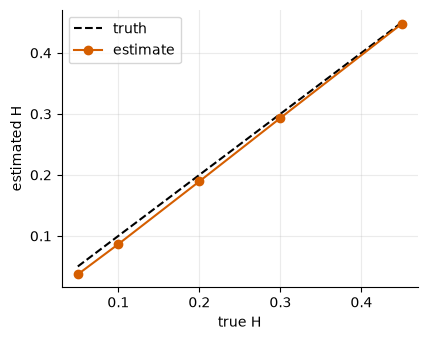

CHECK estimator monotone in H: True [0.037, 0.087, 0.189, 0.293, 0.448]


In [3]:
Hs = [0.05, 0.1, 0.2, 0.3, 0.45]
est = []
for H in Hs:
    _r = simulate_rbergomi(40, 1000, 1.0, H, 1.9, -0.7, 0.235**2, rng=np.random.default_rng(3)); _, V = _r['S'], _r['V']
    h, _ = estimate_hurst(np.log(V))
    est.append(float(np.mean(h)))
fig, ax = plt.subplots(figsize=(4.6, 3.6)); ax.plot(Hs, Hs, 'k--', label='truth'); ax.plot(Hs, est, 'o-', color=PAL[3], label='estimate')
ax.set_xlabel('true H'); ax.set_ylabel('estimated H'); ax.legend(); show(fig)
print('CHECK estimator monotone in H:', bool(np.all(np.diff(est) > 0)), [round(e, 3) for e in est])

## 2. During: training the learned hedgers
All arms are scored with the same ledger (self-financing P&L, proportional cost 10 bp) and a CVaR95 objective. Training and validation CVaR per epoch and seed:

In [4]:
result = run_comparison(CFG)
losses = {a: result['test_losses'][a] for a in ARMS}
rows = []
for a in ARMS:
    per_seed = [cvar_tail_mean(losses[a][k], 0.95) for k in range(CFG['n_seeds'])]
    rows.append(dict(arm=a, cvar95_mean=np.mean(per_seed), cvar95_sd=np.std(per_seed, ddof=1) if len(per_seed) > 1 else 0.0,
                     mean_loss=losses[a].mean()))
tab = pd.DataFrame(rows).set_index('arm')
print('CHECK shared test paths hash:', result['test_paths_sha256'][:12], '| config hash:', result['config_hash'][:12])
print('CHECK all arms leakage-checked:', all(result['leakage_checked'].values()))
print(tab.round(5).to_string())


CHECK shared test paths hash: 387734c9c3c5 | config hash: 747a5fcc6815
CHECK all arms leakage-checked: True


          cvar95_mean  cvar95_sd  mean_loss
arm                                        
bs_delta      0.05651    0.00000    0.02665
leland        0.05631    0.00000    0.02665
ww_band       0.05638    0.00000    0.02597
ffn           0.09382    0.01151    0.02650
gru           0.08700    0.00496    0.02602
sig2          0.08913    0.00254    0.02615


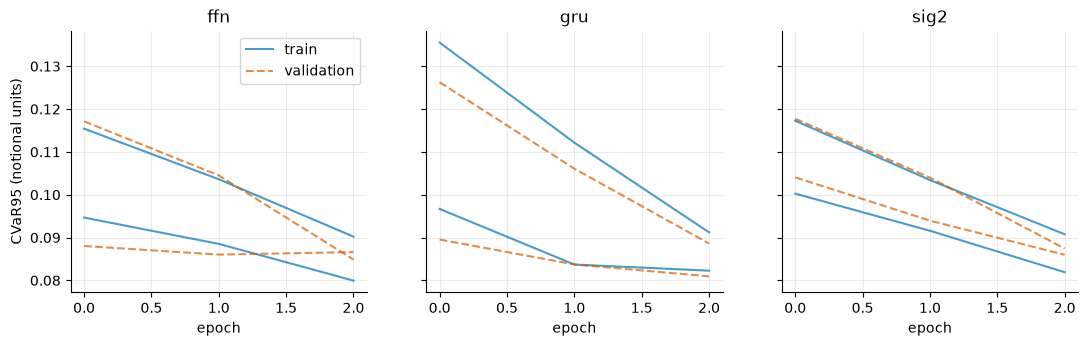

CHECK ffn: val CVaR first->last epoch (seed 0): 0.1171 -> 0.0849
CHECK gru: val CVaR first->last epoch (seed 0): 0.0895 -> 0.0809
CHECK sig2: val CVaR first->last epoch (seed 0): 0.1177 -> 0.0874


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for j, a in enumerate(('ffn', 'gru', 'sig2')):
    for k, h in enumerate(result['histories'][a]):
        ax[j].plot(h['train_cvar'], color=PAL[0], alpha=.7, label='train' if k == 0 else None)
        ax[j].plot(h['val_cvar'], color=PAL[3], ls='--', alpha=.7, label='validation' if k == 0 else None)
    ax[j].set_title(a); ax[j].set_xlabel('epoch')
ax[0].set_ylabel('CVaR95 (notional units)'); ax[0].legend(); show(fig)
for a in ('ffn', 'gru', 'sig2'):
    print(f"CHECK {a}: val CVaR first->last epoch (seed 0):", round(result['histories'][a][0]['val_cvar'][0], 4), '->', round(result['histories'][a][0]['val_cvar'][-1], 4))

## 3. After: how do the methodologies compare?
Loss distributions on the shared test set, then paired bootstrap differences against Black-Scholes delta (per seed, aggregated over seeds, Holm-corrected across the comparisons).

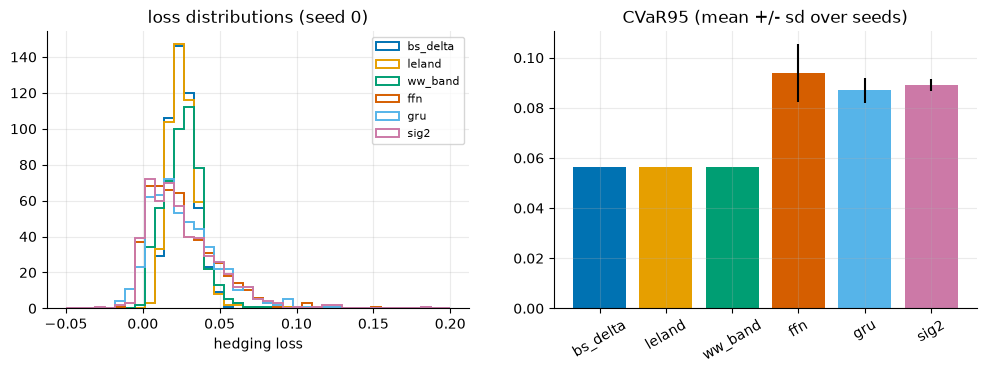

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
bins = np.linspace(-0.05, 0.2, 40)
for i, a in enumerate(ARMS): ax[0].hist(losses[a][0], bins=bins, histtype='step', color=PAL[i], label=a, lw=1.4)
ax[0].set_xlabel('hedging loss'); ax[0].legend(fontsize=8); ax[0].set_title('loss distributions (seed 0)')
ax[1].bar(range(len(ARMS)), tab['cvar95_mean'], yerr=tab['cvar95_sd'], color=PAL[:len(ARMS)])
ax[1].set_xticks(range(len(ARMS))); ax[1].set_xticklabels(ARMS, rotation=30); ax[1].set_title('CVaR95 (mean +/- sd over seeds)')
show(fig)

         diff_vs_bs       lo       hi  seeds_with_positive_diff   p_holm
arm                                                                     
leland     -0.00020 -0.00020 -0.00020                         0  0.12375
ww_band    -0.00013 -0.00013 -0.00013                         0  0.94012
ffn         0.03731 -0.06606  0.14069                         2  0.01996
gru         0.03050 -0.01407  0.07506                         2  0.01996
sig2        0.03262  0.00983  0.05541                         2  0.01996


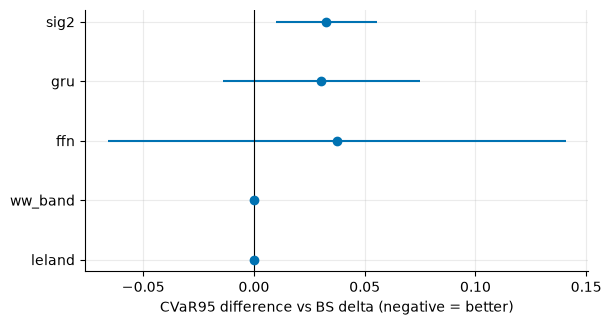

CHECK interval excludes zero: {'leland': True, 'ww_band': True, 'ffn': False, 'gru': False, 'sig2': True}


In [7]:
rows, pv = [], []
for a in ARMS[1:]:
    c = compare_arms(result, a, 'bs_delta', n_boot=500)
    agg = c['aggregate']
    rows.append(dict(arm=a, diff_vs_bs=agg.mean, lo=agg.lo, hi=agg.hi, seeds_with_positive_diff=agg.n_positive))
    pv.append(float(np.mean([r.pvalue for r in c['per_seed']])))
cmp = pd.DataFrame(rows).set_index('arm'); cmp['p_holm'] = holm(pv)[0]
print(cmp.round(5).to_string())
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.errorbar(cmp['diff_vs_bs'], range(len(cmp)), xerr=[cmp['diff_vs_bs'] - cmp['lo'], cmp['hi'] - cmp['diff_vs_bs']], fmt='o', color=PAL[0])
ax.axvline(0, color='k', lw=.8); ax.set_yticks(range(len(cmp))); ax.set_yticklabels(cmp.index)
ax.set_xlabel('CVaR95 difference vs BS delta (negative = better)'); show(fig)
print('CHECK interval excludes zero:', {a: bool(r.lo > 0 or r.hi < 0) for a, r in cmp.iterrows()})

## 4. Limits and reading
* The learned arms use a small budget (2 training seeds, 3 epochs, width 16); a null or negative result against the classical baselines says nothing about larger budgets.
* The statistical unit for the pooled interval is the training seed, not the path; per-seed bootstrap intervals only describe test-path noise.
* The table above is the result, whatever its sign; no arm was selected after looking at the test set.